<a href="https://colab.research.google.com/github/ArshAnan/llm-offload-controller/blob/main/notebooks/01_data_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Mount Drive (optional, for saving checkpoints)
from google.colab import drive
drive.mount('/content/drive')

# Clone your repo
!git clone https://github.com/ArshAnan/llm-offload-controller.git
%cd llm-offload-controller

# Configure git so commits show your name
!git config user.email "arshanand2524@gmail.com"
!git config user.name "ArshAnan"

Mounted at /content/drive
Cloning into 'llm-offload-controller'...
remote: Enumerating objects: 27, done.
remote: Counting objects: 100% (27/27), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 27 (delta 9), reused 5 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (27/27), 10.71 KiB | 10.71 MiB/s, done.
Resolving deltas: 100% (9/9), done.
/content/llm-offload-controller


In [ ]:
import nbformat

path = "notebooks/01_data_preprocessing.ipynb"  # adjust to your actual filename

with open(path, "r") as f:
    nb = nbformat.read(f, as_version=4)

# Strip the broken widget metadata
if "widgets" in nb.metadata:
    del nb.metadata["widgets"]

with open(path, "w") as f:
    nbformat.write(nb, f)

print("Done — widget metadata removed")

Done — widget metadata removed


In [ ]:
# Install HuggingFace datasets
!pip install datasets -q

from datasets import load_dataset
import pandas as pd

# Load just the first 2 months, no failures
ds = load_dataset("lzzmm/BurstGPT", split="train")
df = ds.to_pandas()

# Quick sanity check
print(df.shape)
print(df.head())
print(df.dtypes)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


data/BurstGPT_1.csv:   0%|          | 0.00/52.3M [00:00<?, ?B/s]

data/BurstGPT_2.csv:   0%|          | 0.00/145M [00:00<?, ?B/s]

data/BurstGPT_without_fails_1.csv:   0%|          | 0.00/51.4M [00:00<?, ?B/s]

data/BurstGPT_without_fails_2.csv:   0%|          | 0.00/142M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10476680 [00:00<?, ? examples/s]

(10476680, 6)
   Timestamp    Model  Request tokens  Response tokens  Total tokens  \
0          5  ChatGPT             472               18           490   
1         45  ChatGPT            1087              230          1317   
2        118    GPT-4             417              276           693   
3        185  ChatGPT            1360              647          2007   
4        214  ChatGPT             185              215           400   

           Log Type  
0  Conversation log  
1  Conversation log  
2  Conversation log  
3  Conversation log  
4  Conversation log  
Timestamp           int64
Model              object
Request tokens      int64
Response tokens     int64
Total tokens        int64
Log Type           object
dtype: object


count    1.037701e+07
mean     1.007456e+00
std      3.834865e+01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      3.713300e+04
Name: inter_arrival, dtype: float64
count    1.037701e+07
mean     3.592198e+02
std      4.846696e+02
min      7.000000e+00
25%      1.890000e+02
50%      2.180000e+02
75%      2.910000e+02
max      3.140700e+04
Name: req_tokens, dtype: float64


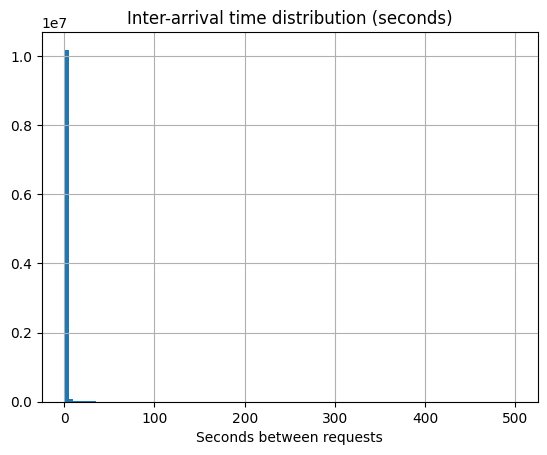

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Use the df already loaded from HuggingFace in the previous cell
df.columns = ['timestamp', 'model', 'req_tokens', 'resp_tokens', 'total_tokens', 'log_type']

# Drop zero-token rows if using the non-fail version (just in case)
df = df[df['resp_tokens'] > 0].copy()

# Compute inter-arrival times
df = df.sort_values('timestamp').reset_index(drop=True)
df['inter_arrival'] = df['timestamp'].diff().fillna(0)

# Basic stats — this is the burstiness you'll feed into the simulator
print(df['inter_arrival'].describe())
print(df['req_tokens'].describe())

# Plot inter-arrival distribution
df['inter_arrival'].clip(0, 500).hist(bins=100)
plt.title("Inter-arrival time distribution (seconds)")
plt.xlabel("Seconds between requests")
plt.show()

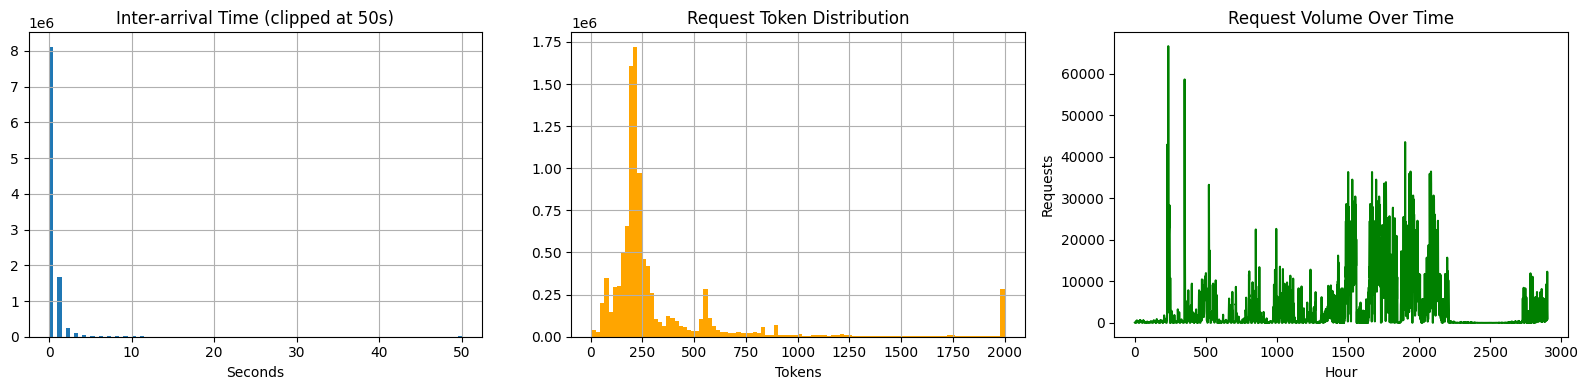

In [ ]:
# ── Burst visualization ────────────────────────────────────────────
import os

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Inter-arrival (clipped to see the spike at 0)
df['inter_arrival'].clip(0, 50).hist(bins=100, ax=axes[0])
axes[0].set_title("Inter-arrival Time (clipped at 50s)")
axes[0].set_xlabel("Seconds")

# 2. Request token distribution
df['req_tokens'].clip(0, 2000).hist(bins=100, ax=axes[1], color='orange')
axes[1].set_title("Request Token Distribution")
axes[1].set_xlabel("Tokens")

# 3. Requests over time (binned by hour) — shows daily periodicity
df['hour_bin'] = df['timestamp'] // 3600
hourly = df.groupby('hour_bin').size()
hourly.plot(ax=axes[2], color='green')
axes[2].set_title("Request Volume Over Time")
axes[2].set_xlabel("Hour")
axes[2].set_ylabel("Requests")

plt.tight_layout()
os.makedirs("results", exist_ok=True)
plt.savefig("results/eda_overview.png", dpi=150)
plt.show()

In [ ]:
# What fraction of requests arrive within 1 second of the previous?
burst_frac = (df['inter_arrival'] <= 1).mean()
print(f"Burst fraction (inter-arrival ≤ 1s): {burst_frac:.1%}")

# P99 request token length
p99 = df['req_tokens'].quantile(0.99)
print(f"P99 request token length: {p99:.0f} tokens")

# Peak vs median hourly load ratio
hourly = df.groupby('hour_bin').size()
print(f"Peak/median load ratio: {hourly.max() / hourly.median():.1f}x")

Burst fraction (inter-arrival ≤ 1s): 94.4%
P99 request token length: 2991 tokens
Peak/median load ratio: 129.6x


Feature Engineering

In [ ]:
# Feature Engineering
df['arrival_rate'] = 1 / df['inter_arrival'].replace(0, 0.001)
df['hour_of_day'] = (df['timestamp'] % 86400) // 3600
df['is_gpt4'] = (df['model'] == 'GPT-4').astype(int)
df['is_large_request'] = (df['req_tokens'] > 1000).astype(int)

print(df[['arrival_rate', 'hour_of_day', 'is_gpt4', 'is_large_request']].head(10))
print("\nLarge request fraction:", df['is_large_request'].mean().round(3))

   arrival_rate  hour_of_day  is_gpt4  is_large_request
0   1000.000000            0        0                 0
1   1000.000000            0        0                 0
2      0.025000            0        0                 1
3   1000.000000            0        0                 1
4      0.013699            0        1                 0
5   1000.000000            0        1                 0
6      0.014925            0        0                 1
7   1000.000000            0        0                 1
8      0.034483            0        0                 0
9   1000.000000            0        0                 0

Large request fraction: 0.055


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df[['req_tokens_norm', 'inter_arrival_norm', 'arrival_rate_norm']] = scaler.fit_transform(
    df[['req_tokens', 'inter_arrival', 'arrival_rate']]
)

print(df[['req_tokens', 'req_tokens_norm', 'inter_arrival', 'inter_arrival_norm', 'arrival_rate', 'arrival_rate_norm']].head(10))

   req_tokens  req_tokens_norm  inter_arrival  inter_arrival_norm  \
0         472         0.014809            0.0            0.000000   
1         472         0.014809            0.0            0.000000   
2        1087         0.034395           40.0            0.001077   
3        1087         0.034395            0.0            0.000000   
4         417         0.013057           73.0            0.001966   
5         417         0.013057            0.0            0.000000   
6        1360         0.043089           67.0            0.001804   
7        1360         0.043089            0.0            0.000000   
8         185         0.005669           29.0            0.000781   
9         185         0.005669            0.0            0.000000   

   arrival_rate  arrival_rate_norm  
0   1000.000000           1.000000  
1   1000.000000           1.000000  
2      0.025000           0.000025  
3   1000.000000           1.000000  
4      0.013699           0.000014  
5   1000.000000   

The 1000's are dominating even in the normalized arrival rate. We will need to fix that.

We will be using a rolling window method to see how many requests arrived in the last 10 seconds

In [ ]:
# Fix arrival rate — rolling mean of inter-arrival over last 10 requests
df['arrival_rate'] = df['inter_arrival'].rolling(10).mean().fillna(0)

# Normalize
scaler = MinMaxScaler()
df[['req_tokens_norm', 'inter_arrival_norm', 'arrival_rate_norm']] = scaler.fit_transform(
    df[['req_tokens', 'inter_arrival', 'arrival_rate']]
)

# TODO: arrival_rate_norm has many zeros due to simultaneous arrivals (94.4% inter_arrival = 0)
# Revisit after pipeline is working — consider timestamp-based binning instead

print(df[['req_tokens_norm', 'inter_arrival_norm', 'arrival_rate_norm']].head(30))

    req_tokens_norm  inter_arrival_norm  arrival_rate_norm
0          0.014809            0.000000           0.000000
1          0.014809            0.000000           0.000000
2          0.034395            0.001077           0.000000
3          0.034395            0.000000           0.000000
4          0.013057            0.001966           0.000000
5          0.013057            0.000000           0.000000
6          0.043089            0.001804           0.000000
7          0.043089            0.000000           0.000000
8          0.005669            0.000781           0.000000
9          0.005669            0.000000           0.004494
10         0.018439            0.000512           0.004903
11         0.018439            0.000000           0.004903
12         0.000955            0.000754           0.004645
13         0.000955            0.000000           0.004645
14         0.001497            0.000162           0.003204
15         0.001497            0.000000           0.0032

Sequence Windowing

In [ ]:
# Sequence Windowing — give the agent a view of the last 10 requests
window_size = 10
df['rolling_req_tokens'] = df['req_tokens_norm'].rolling(window_size).mean().fillna(0)
df['rolling_inter_arrival'] = df['inter_arrival_norm'].rolling(window_size).mean().fillna(0)

print(df[['req_tokens_norm', 'rolling_req_tokens', 'inter_arrival_norm', 'rolling_inter_arrival']].head(15))

    req_tokens_norm  rolling_req_tokens  inter_arrival_norm  \
0          0.014809            0.000000            0.000000   
1          0.014809            0.000000            0.000000   
2          0.034395            0.000000            0.001077   
3          0.034395            0.000000            0.000000   
4          0.013057            0.000000            0.001966   
5          0.013057            0.000000            0.000000   
6          0.043089            0.000000            0.001804   
7          0.043089            0.000000            0.000000   
8          0.005669            0.000000            0.000781   
9          0.005669            0.022204            0.000000   
10         0.018439            0.022567            0.000512   
11         0.018439            0.022930            0.000000   
12         0.000955            0.019586            0.000754   
13         0.000955            0.016242            0.000000   
14         0.001497            0.015086            0.00

Train/Test Split

In [ ]:
# Train/Test Split — split by time, not randomly
split = int(len(df) * 0.8)
train_df = df.iloc[:split]
test_df  = df.iloc[split:]

print(f"Train size: {len(train_df):,} rows")
print(f"Test size:  {len(test_df):,} rows")
print(f"\nTrain timestamp range: {train_df['timestamp'].min()} to {train_df['timestamp'].max()}")
print(f"Test timestamp range:  {test_df['timestamp'].min()} to {test_df['timestamp'].max()}")

Train size: 8,301,611 rows
Test size:  2,075,403 rows

Train timestamp range: 5 to 7208027
Test timestamp range:  7208027 to 10454395


Saving Data

In [ ]:
# Save processed data
import os
os.makedirs("data", exist_ok=True)

train_df.to_csv("data/train_processed.csv", index=False)
test_df.to_csv("data/test_processed.csv", index=False)

print(f"Train saved: {os.path.getsize('data/train_processed.csv') / 1e6:.1f} MB")
print(f"Test saved:  {os.path.getsize('data/test_processed.csv') / 1e6:.1f} MB")

Train saved: 1214.2 MB
Test saved:  300.2 MB


In [20]:
# Save processed data to Google Drive for persistence
drive_path = "/content/drive/MyDrive/llm-offload-controller/data/"
os.makedirs(drive_path, exist_ok=True)

train_df.to_csv(drive_path + "train_processed.csv", index=False)
test_df.to_csv(drive_path + "test_processed.csv", index=False)

# Also cache the raw df so you never re-download from HuggingFace again
df.to_csv(drive_path + "burstgpt_raw.csv", index=False)

print(f"Train saved:  {os.path.getsize(drive_path + 'train_processed.csv') / 1e6:.1f} MB")
print(f"Test saved:   {os.path.getsize(drive_path + 'test_processed.csv') / 1e6:.1f} MB")
print(f"Raw saved:    {os.path.getsize(drive_path + 'burstgpt_raw.csv') / 1e6:.1f} MB")

Train saved:  1214.2 MB
Test saved:   300.2 MB
Raw saved:    1514.4 MB
